<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [17]</a>'.</span>

Author: Nicolas Legrand <nicolas.legrand@cfin.au.dk>

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import numpy as np
from metadPy import sdt
from metadPy.utils import trials2counts, discreteRatings
from metadPy.plotting import plot_confidence
from systole.plots import plot_raw, plot_rr

from bokeh.io import output_notebook
from bokeh.plotting import show
output_notebook()

sns.set_context('talk')
%matplotlib inline

Loading BokehJS ...

# Heart Rate Discrimination task - Summary results

This notebook introduces basic analysis steps, plots and quality check for the Heart Rate Discrimination task. The current version use data from a young and healthy participant tested with the default task parameters implemented in the launcher.py file (80 trials per condition, 30 using a 1-Up/1-Down staircase and 50 using the Psi method.

The target directory is defined by the `path` variable and should include the following files: `final.txt` (the behavioural data), `Intero_posterior.npy` and `Extero_posterior.npy` (the posterior estimates) and `signal.txt` (the PPG signal time series during the interoception trials).

**Import data**

In [2]:
# The values of these variables are going to be filled by papermill
subject = "."
path = "." 

In [3]:
# Parameters
subject = "214"
path = "/home/nicolas/git/HauntedHearts/"


In [4]:
resultPath = f"{path}/data/raw/{subject}HRD/"
reportPath = f"{path}/reports"

In [5]:
resultsFiles = os.listdir(resultPath)
# Logs dataframe
df = pd.read_csv(os.path.join(resultPath, [file for file in resultsFiles if file.endswith('final.txt')][0]))

# History of posteriors distribution
try:
    interoPost = np.load(os.path.join(resultPath, [file for file in resultsFiles if file.endswith('Intero_posterior.npy')][0]))
except:
    interoPost = None
try:
    exteroPost = np.load(os.path.join(resultPath, [file for file in resultsFiles if file.endswith('Extero_posterior.npy')][0]))
except:
    exteroPost = None

# PPG signal
signal_df = pd.read_csv(os.path.join(resultPath, [file for file in resultsFiles if file.endswith('signal.txt')][0]))
signal_df['Time'] = np.arange(0, len(signal_df))/1000 # Create time vector

# Response time

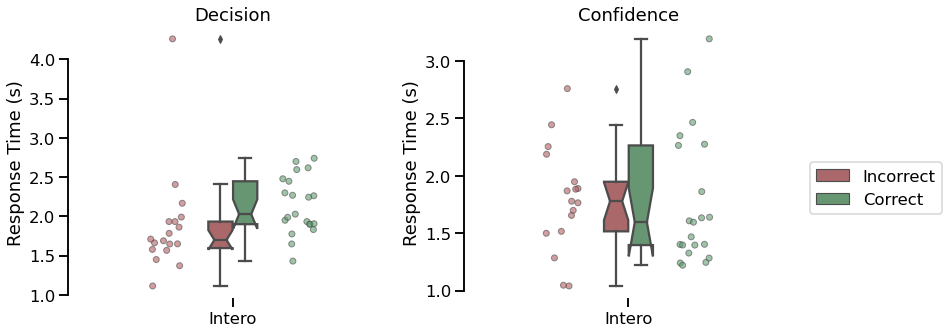

In [6]:
palette = ['#b55d60', '#5f9e6e']

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for i, task, title in zip([0, 1], ['DecisionRT', 'ConfidenceRT'], ['Decision', 'Confidence']):
    sns.boxplot(data=df, x='Modality', y=task, hue='ResponseCorrect',
                palette=palette, width=.15, notch=True, ax=axs[i])
    sns.stripplot(data=df, x='Modality', y=task, hue='ResponseCorrect',
                  dodge=True, linewidth=1, size=6, palette=palette, alpha=.6, ax=axs[i])
    axs[i].set_title(title)
    axs[i].set_ylabel('Response Time (s)')
    axs[i].set_xlabel('')
    axs[i].get_legend().remove()
sns.despine(trim=10)

handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles[0:2], ['Incorrect', 'Correct'], bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.)

Response time distribution for the decision and the confidence rating phases for correct (red) and incorrect (green) responses.

# Metacognition

SDT estimate for decision 1 perforamces (d' and criterion)

In [7]:
for i, cond in enumerate(['Intero', 'Extero']):
    this_df = df[df.Modality == cond].copy()
    if len(this_df) > 0:
        try:

            this_df['Stimuli'] = (this_df.responseBPM > this_df.listenBPM)
            this_df['Responses'] = (this_df.Decision == 'More')

            hit, miss, fa, cr = this_df.scores()
            hr, far = sdt.rates(hits=hit, misses=miss, fas=fa, crs=cr)
            d, c = sdt.dprime(hit_rate=hr, fa_rate=far), sdt.criterion(hit_rate=hr, fa_rate=far)

            print(f'Condition: {cond} - d-prime: {d} - criterion: {c}')
        except:
            print("Impossible to fit SDT models.")

Condition: Intero - d-prime: 0.6744897501960817 - criterion: 0.33724487509804085


Invalid ratings


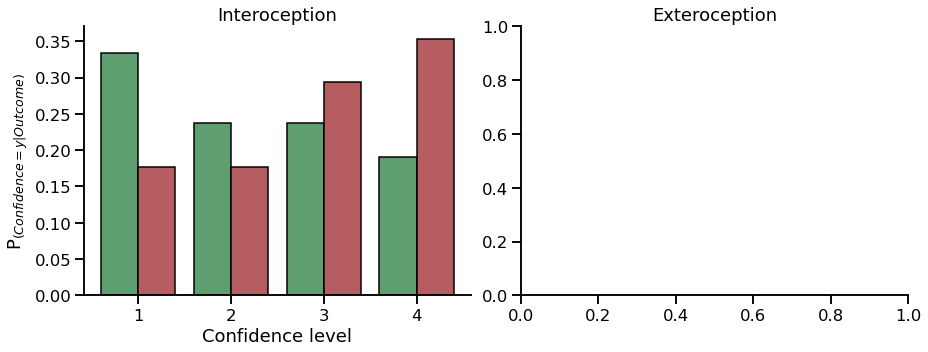

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

for i, cond in enumerate(['Intero', 'Extero']):
    try:
        this_df = df[(df.Modality == cond) & (df.RatingProvided == 1)]
        this_df = this_df[~this_df.Confidence.isnull()]
        new_confidence, _ = discreteRatings(this_df.Confidence)
        this_df['Confidence'] = new_confidence
        this_df['Stimuli'] = (this_df.Alpha > 0).astype('int')
        this_df['Responses'] = (this_df.Decision == 'More').astype('int')
        nR_S1, nR_S2 = trials2counts(data=this_df)
        plot_confidence(nR_S1, nR_S2, ax=axs[i])
        axs[i].set_title(f'{cond}ception')
    except:
        print('Invalid ratings')
        this_df = df[df.Modality == cond]
        sns.histplot(this_df[this_df.ResponseCorrect==1].Confidence, ax=axs[i], color="#5f9e6e",)
        sns.histplot(this_df[this_df.ResponseCorrect==0].Confidence, ax=axs[i], color="#b55d60")
        axs[i].set_title(f'{cond}ception')
sns.despine()
plt.tight_layout()

Distribution of confidence ratings for correct (green) and incorrect (red) trials. Overlapping distribution suggests that the subjective confidence in the decision was not predictive of decision performances.

# Psychophysics

Distribution of the intensities values.

/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


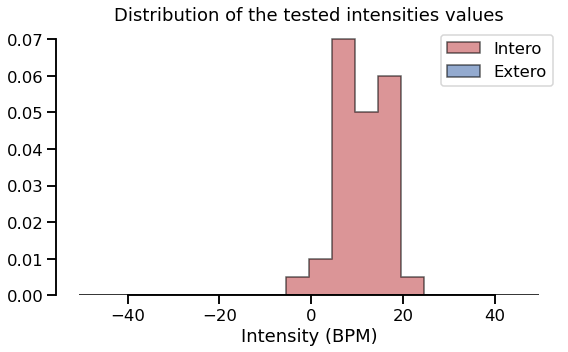

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

for cond, col in zip(['Intero', 'Extero'], ['#c44e52', '#4c72b0']):
    this_df = df[df.Modality == cond]
    axs.hist(this_df.Alpha, color=col, bins=np.arange(-50.5, 50.5, 5), histtype='stepfilled',
             ec="k", density=True, align='mid', label=cond, alpha=.6)
axs.set_title('Distribution of the tested intensities values')
axs.set_xlabel('Intensity (BPM)')
plt.legend()
sns.despine(trim=10)
plt.tight_layout()

## Staircases

### Psi

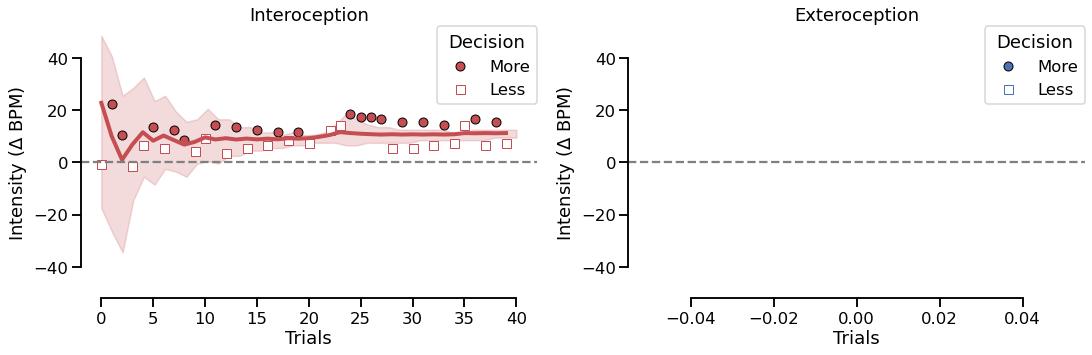

In [10]:
if sum(df.TrialType == 'psi') > 0:

    fig, axs = plt.subplots(figsize=(18, 5), nrows=1, ncols=2)

    # Plot confidence interval for each staircase
    def ci(x):
        return np.where(np.cumsum(x) / np.sum(x) > .025)[0][0], \
               np.where(np.cumsum(x) / np.sum(x) < .975)[0][-1]

    try:
        for i, stair, col, modality in zip([0, 1], 
                                 [interoPost, exteroPost], 
                                 ['#c44e52', '#4c72b0'],
                                ['Intero', 'Extero']):
            this_df = df[(df.Modality == modality) & (df.TrialType != 'UpDown')]
            ciUp, ciLow = [], []
            for t in range(stair.shape[0]):
                up, low = ci(stair.mean(2)[t])
                rg = np.arange(-50.5, 50.5)
                ciUp.append(rg[up])
                ciLow.append(rg[low])

            axs[i].fill_between(x=np.linspace(0, len(this_df), len(ciUp)),
                                y1=ciLow,
                                y2=ciUp,
                                color=col, alpha=.2)
    except:
        pass


    # Staircase traces
    for i, modality, col in zip([0, 1], ['Intero', 'Extero'], ['#c44e52', '#4c72b0']):
        this_df = df[(df.Modality == modality) & (df.TrialType != 'UpDown')]

        # Show UpDown staircase traces
        axs[i].plot(np.arange(0, len(this_df))[this_df.TrialType == 'high'], 
                        this_df.Alpha[this_df.TrialType == 'high'], linestyle='--', color=col, linewidth=2)
        axs[i].plot(np.arange(0, len(this_df))[this_df.TrialType == 'low'], 
                        this_df.Alpha[this_df.TrialType == 'low'], linestyle='-', color=col, linewidth=2)

        # Use different colors for psi and catch trials
        for trialCond, pointCol in zip(['psi', 'psiCatchTrial'], [col, 'gray']):
            axs[i].plot(np.arange(0, len(this_df))[(this_df.Decision == 'More') & (this_df.TrialType == trialCond)], 
                        this_df.Alpha[(this_df.Decision == 'More') & (this_df.TrialType == trialCond)], 
                        pointCol, marker='o', linestyle='', markeredgecolor='k', label=cond)
            axs[i].plot(np.arange(0, len(this_df))[(this_df.Decision == 'Less') & (this_df.TrialType == trialCond)],
                        this_df.Alpha[(this_df.Decision == 'Less') & (this_df.TrialType == trialCond)], 
                        'w', marker='s', linestyle='', markeredgecolor=pointCol, label=modality)

        # Psi trials
        axs[i].plot(np.arange(len(this_df))[this_df.TrialType=='psi'],
                    this_df[this_df.TrialType=='psi'].EstimatedThreshold, linestyle='-', color=col, linewidth=4)
    
        axs[i].axhline(y=0, linestyle='--', color = 'gray')
        handles, labels = axs[i].get_legend_handles_labels()
        axs[i].legend(handles[0:2], ['More', 'Less'], borderaxespad=0., title='Decision')
        axs[i].set_ylabel('Intensity ($\Delta$ BPM)')
        axs[i].set_xlabel('Trials')
        axs[i].set_ylim(-52, 52)
        axs[i].set_title(modality+'ception')
        sns.despine(trim=10, ax=axs[i])
        plt.gcf()

This figure represents the evolution of threshold estimate across trials for the Interoception and Exteroception condition. Shaded areas represent the 95% confidence interval of the threshold estimate by Psi. For each condition, the first 30 trials (connected with dashed lines) were allocated to an Up/Down method (2 interleaved staircases starting a -40.5 or 40 respectively). The intensities and responses were included in the Psi staircase to maximize the amount of information included. The remaining 50 trials were monitored by the Psi staircase only. This dual estimation was implemented to estimate the reliability of the estimation of threshold using an up/down procedure, as compared to a longer psi procedure.

# Psychometric function

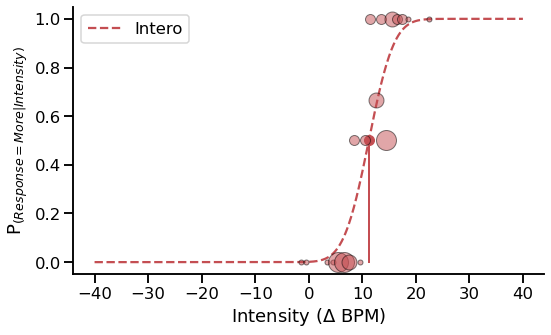

In [11]:
sns.set_context('talk')
fig, axs = plt.subplots(figsize=(8, 5))
for i, modality, col in zip((0, 1), ['Extero', 'Intero'], ['#4c72b0', '#c44e52']):
    
    this_df = df[(df.Modality == modality) & (df.TrialType == 'psi')]
    if len(this_df) > 0:
        t, s = this_df.EstimatedThreshold.iloc[-1], this_df.EstimatedSlope.iloc[-1]
        # Plot Psi estimate of psychometric function
        axs.plot(np.linspace(-40, 40, 500), 
                (norm.cdf(np.linspace(-40, 40, 500), loc=t, scale=s)),
                '--', color=col, label=modality)
        # Plot threshold
        axs.plot([t, t], [0, .5], color=col, linewidth=2)
        axs.plot(t, .5, 'o', color=col, markersize=10)

        # Plot data points
        for ii, intensity in enumerate(np.sort(this_df.Alpha.unique())):
            resp = sum((this_df.Alpha == intensity) & (this_df.Decision == 'More'))
            total = sum(this_df.Alpha == intensity)
            axs.plot(intensity, resp/total, 'o', alpha=0.5, color=col, 
                     markeredgecolor='k', markersize=total*5)
plt.ylabel('P$_{(Response = More|Intensity)}$')
plt.xlabel('Intensity ($\Delta$ BPM)')
plt.tight_layout()
plt.legend()
sns.despine()

Psychometric functions fitted using the estimated threshold and slope from the final trial on each condition. The size of the circles reflects the proportion of responses for each intensity level.

# Pulse oximeter

## Visualization of PPG signal
Here, we plot the raw PPG signal as recorded during the task using the Nonin pulse oximeter. This signal is also used to produce the new intensity values proposed by the staircases, and artefacts in this time series might induce a strong bias in the overall estimation of the psychophysics parameters. It is therefore central to assess signal quality for each participant. For each experimental block (sequence of trials interleaved with breaks), we show the raw PPG traces, the derived instantaneous heart rate and the distribution of the events (start of the recording).

In [12]:
# Copy behaviral data
this_df = df.copy()

# The raw PPG signal 
ppg_list = [f for f in os.listdir(resultPath) if f.startswith(f"{subject}_ppg_")]

for ppg in ppg_list:
    
    # Load the PPG recording for this block of trials
    ppg_df = pd.read_csv(f"{resultPath}{ppg}")
    
    # Find the start of the recording for each trials
    triggers_idx = np.where(ppg_df.Channel_0 == 2)[0]
    
    # Find Intero and Extero trials (if any)
    intero_triggers = triggers_idx[np.where(df[:len(triggers_idx)].Modality == "Intero")]
    extero_triggers = triggers_idx[np.where(df[:len(triggers_idx)].Modality == "Extero")]

    # Drop the current trials from the temp. behavior data frame
    this_df = this_df[len(triggers_idx):]
        
    # Define the events parameters for plotting on the top of the
    # instantaneous heart rate trace.
    events_params = {
        "triggers_idx": [intero_triggers, extero_triggers],
        "labels": ["Interoception", "Exteroception"],
        "tmin": -0.5,
        "tmax": 5.0,
        "sfreq": 75,
        "palette": [sns.xkcd_rgb["pale red"], sns.xkcd_rgb["denim blue"]],
    }
    
    # Show raw signal + instantaneous heart rate + events
    show(
        plot_raw(
            signal=ppg_df.signal.to_numpy(), sfreq=75,
            show_heart_rate=True, figsize=200,
            events_params=events_params, backend="bokeh"
                )
    )

## Visualization of the haunted house ECG recording

In [13]:
# Compute starting and ending times for the task
summary_df = pd.read_csv(f"{path}/data/raw/summary.csv", sep=",")

In [14]:
summary_df.Enter_time = pd.to_datetime(summary_df.Date + " " +  summary_df.Enter_time)
summary_df.Exit_time = pd.to_datetime(summary_df.Date + " " +  summary_df.Exit_time)
summary_df["TaskDuration"] = summary_df.Exit_time - summary_df.Enter_time 
summary_df["TaskDuration"] = summary_df["TaskDuration"].dt.total_seconds()

In [15]:
# Extract RR time serie
try:
    rr = pd.read_csv(
        f"{path}/data/heartrate/" + [file for file in os.listdir(f"{path}/data/heartrate/") if file.startswith(f"P{subject} ")][0],
        skiprows=[2], header=3, sep=";"
    ).ArtifactCorrectedRRVector.to_numpy()

    artifacts = pd.read_csv(
        f"{path}/data/heartrate/" + [file for file in os.listdir(f"{path}/data/heartrate/") if file.startswith(f"P{subject} ")][0],
        skiprows=[2], header=3, sep=";"
    ).RawArtifactVector.to_numpy()

    # When the recording started
    start_recording = pd.to_datetime(
        pd.read_csv(
            f"{path}/data/heartrate/" + [file for file in os.listdir(f"{path}/data/heartrate/") if file.startswith(f"P{subject} ")][0],
            sep=";", nrows=1, 
        ).loc[0][0][12:],
        dayfirst=True
    )

except IndexError:
    print(f"No data for {subject}")


In [16]:
start_delay = (summary_df[summary_df.participant_id == int(subject)].Enter_time - start_recording).dt.total_seconds().values[0]

duration = summary_df[summary_df.participant_id == int(subject)].TaskDuration.values[0]

# Remove pre-recording time
artifacts = artifacts[(np.cumsum(rr) / 1000) > start_delay]
rr = rr[(np.cumsum(rr) / 1000) > start_delay]

# Remove post-recording time
artifacts = artifacts[(np.cumsum(rr) / 1000) < duration]
rr = rr[(np.cumsum(rr) / 1000) < duration]

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [17]:
print(
    f"{round((sum(artifacts) / len(artifacts)) * 100, 2)} % of the RR interval were corrected due to artefacts."
)

ZeroDivisionError: division by zero

In [ ]:
show(
    plot_rr(rr=rr, input_type="rr_ms", backend="bokeh", unit="bpm")
)